# Introduction to SOLPS analysis in python

This jupyter notebook should give a brief introduction to SOLPS-ITER analysis, mostly leveraging the excellent scripts written by Mike Kryjak that be found in [sdtools/code_comparison](https://github.com/mikekryjak/sdtools/tree/main/code_comparison)(although they may not be free of their own bugs). The basis of this analysis is designed to be similar to hermes-3 using xhermes, however the lack of meta-data output from SOLPS makes x-array functionality limited (hence why the data structure used by Mike is simple a dictionary). 

Hopefully we can continue to build on Mike's work, so please make your own fork of sdtools so that if you do make any significant changes they can be merged with the main repo.

The sdtool scripts have their own library dependancies, I would reccomend creating a seperate virtual environment and pip installing the attached requirements.txt which should install most libraries you will need to analyse SOLPS or Hermes-3 data.

So lets get started

# Linking sdtools and loading packages

First install any python packages we might want for the analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys, pathlib

# ect ect

Because sdtools are a library of scripts we then need to add it to our path before we can run them

In [2]:
sys.path.append(os.path.join('/Users/lloyd/Documents/hermes_dir/analysis/sdtools'))  # Adjust the path as necessary
from code_comparison.solps_pp import * # Most solps post-processing functions are found here



# SOLPS I/O

We now need to read in the SOLPS data. This is mostly stored in David Moulton balance.nc file, Mike's SOLPScase class will search the SOLPS data directory for the balance file, so make sure to give the path as place/where/balance/nc/is NOT place/where/balance/nc/is/balance.nc

In [3]:
case = SOLPScase('/Users/lloyd/Documents/solps/puff=13.0e21_pump=0.001_divchiconstfix_bcmom2_visper1_rxf0p1_parmvsa2_redoutpfrtrans_pufflfs_pin1.0')  # No need to add balance.nc


# Finding variable names

Now this is the truly painful part... SOLPS doesn't attach metadata to variables, which means you will have to consult the 718 page cursed tome that is the SOLPS user manual to find what specific variable names represent or which units they are in. While there is some intuition for this, sometimes its just odd such as 'fhex_strange', which I believe is the electron 'strange' heatflux in the x direction, but I can't find any further information on it. David Moulton has also added his own variables to this which he uses in some of his balance scripts for which there is **no** documentation... which is also painful. Ultimately if you need to know, asking David is the quickest way to go. 

Now... when it comes to coordinates. I **Believe** that SOLPS x coordinate parallel to the fieldline and y coordinate is purpendicular to the field line. This means that to get the parallel electron conductive heatflux we would want the 'fhex_cond' variable. Annoyingly this coordinate is opposite in Hermes-3, so watch out for that. 

Regarding units, the SOLPScase automatically converts some of the more strange ones (such as electron temperature being in joules natively in SOLPS) to follow the more standard plasma physics ones we're familiar with (changing Te to eV for instance). This is not complete however, so do check in SOLPScase to double check.

One can print the available SOLPS variables like so:

In [4]:
print(case.params)

['crx', 'cry', 'bb', 'hx', 'hy', 'hz', 'vol', 'gs', 'qz', 'am', 'mp', 'ev', 'leftix', 'leftiy', 'rightix', 'rightiy', 'topix', 'topiy', 'bottomix', 'bottomiy', 'jxi', 'jxa', 'jsep', 'species', 'b2mndr_eirene', 'b2mndr_hz', 'za', 'fna_pinch', 'fna_pll', 'fna_drift', 'fna_drift_50', 'fna_ch', 'fna_nanom', 'fna_panom', 'fna_pschused', 'fna_vsprcur', 'fna_tot', 'b2stbr_phys_sna_bal', 'b2stbr_bas_sna_bal', 'b2stbr_first_flight_sna_bal', 'b2stbc_sna_bal', 'b2stbm_sna_bal', 'ext_sna_bal', 'b2stel_sna_ion_bal', 'b2stel_sna_rec_bal', 'b2stcx_sna_bal', 'b2srsm_sna_bal', 'b2srdt_sna_bal', 'b2srst_sna_bal', 'tot_sna_bal', 'resco', 'fmo_flua', 'fmo_cvsa', 'fmo_hybr', 'fmo_b2nxfv', 'fmo_tot', 'b2stbr_phys_smo_bal', 'b2stbr_bas_smo_bal', 'b2stbc_smo_bal', 'b2stbm_smo_bal', 'ext_smo_bal', 'b2stel_smq_ion_bal', 'b2stel_smq_rec_bal', 'b2stcx_smq_bal', 'b2srsm_smo_bal', 'b2srdt_smo_bal', 'b2srst_smo_bal', 'b2sifr_smoch_bal', 'b2sifr_smotf_ehxp_bal', 'b2sifr_smotf_cthe_bal', 'b2sifr_smotf_cthi_bal', 'b2si

or in a more readable format:

In [5]:
params_sorted = sorted(case.params)
n_cols = 4
params_array = np.array_split(params_sorted, n_cols)

for row in zip(*params_array):
    print(f"{row[0]:<30} {row[1]:<30} {row[2] if len(row) > 2 else '':<30}")

Babs                           eirene_mc_papl_sna_bal         fmoy_C+1_flua                 
Bpol                           eirene_mc_piat_sna_bal         fmoy_C+1_tot                  
Btor                           eirene_mc_piio_sna_bal         fmoy_C+2_cvsa                 
Btot                           eirene_mc_piml_sna_bal         fmoy_C+2_flua                 
Bx                             eirene_mc_pipl_sna_bal         fmoy_C+2_tot                  
By                             eirene_mc_pmat_sna_bal         fmoy_C+3_cvsa                 
Bz                             eirene_mc_pmel_sne_bal         fmoy_C+3_flua                 
M                              eirene_mc_pmio_sna_bal         fmoy_C+3_tot                  
NVd+                           eirene_mc_pmml_sna_bal         fmoy_C+4_cvsa                 
Na                             eirene_mc_pmpl_sna_bal         fmoy_C+4_flua                 
Ne                             eirene_mc_pppl_sna_bal         fmoy_C+4

# Plotting in 2D

Now While I don't think that poloidal cross section plots are 'that' useful (they are quite pretty at least), they can still be useful to get an overall view, and sanity check simulations quickly. This can be done quickly using Mikes plot_2d() function like so:

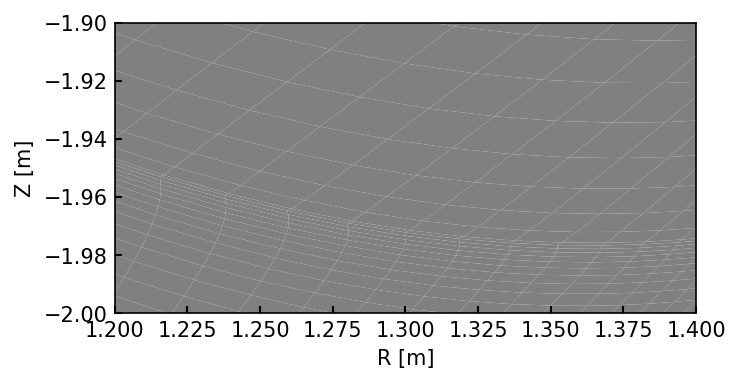

In [6]:
vmin, vmax = 0, 10
case.plot_2d('Td+',grid_only = True, xlim = (1.2,1.4), ylim = (-2.0,-1.9),
             vmin=vmin, vmax=vmax,separatrix = False)

Which has many useful arguements, so we can restrict our interest to the divertor, and plot the atomic neutral pressure while constraining the color bar. Just consult solps_pp.py to find all the methods that are available.

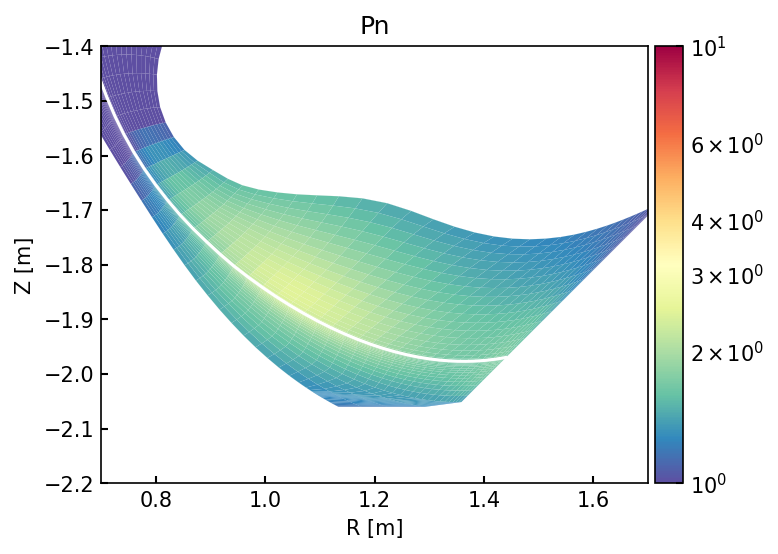

In [7]:
vmin = 1e0
vmax = 1e1

case.plot_2d("Pn", logscale=True, xlim = (0.7,1.7), ylim = (-2.2,-1.4), 
            separatrix = True, vmin = vmin, vmax = vmax)

# Plotting in 1D 

Now often its more useful to see our 2D data either radially or parallel as its far easier to interpret. 

We will begin with parallel to the field line.

## Plotting poloidal(parallel) data
The SOLPScase() has a method called get_poloidal_data() that we can use to plot along the parallel direction of a particular 'sol ring', this just means the specific flux surface outside of the last closed flux surface. As an example the seperatrix is donated as the 0th sol ring (in the method it is refered to as sepadd -> seperatrix is sepadd = 0). 

An example of its use is below:

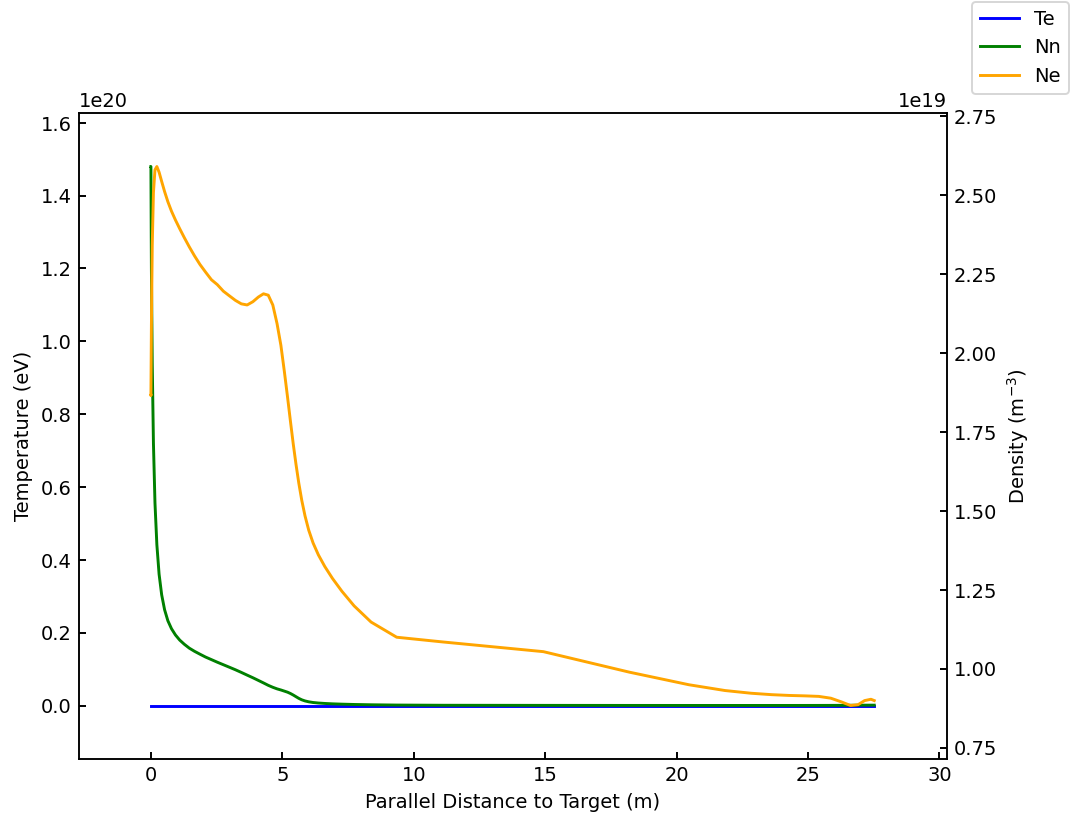

In [12]:
# Must specify specific variables from the balance file

params = ['Ne', 'Te', 'Nn'] # as an example

fline = case.get_1d_poloidal_data( params, # list of parameters to extract
                             region= 'outer_lower', # this represents the path from OMP to outer lower divertor, and mainly what we will need
                             sepadd=0,  # 0 is the separatrix
                             target_first=True) # Plots the target on left side of plot, useful for log x scale

fig, ax = plt.subplots(figsize=(8,6))
ax2 = ax.twinx()

# Plot along the parallel distance to the target
ax2.plot(fline['Spar'], fline['Ne'], label='Ne', color='orange')
ax.plot(fline['Spar'], fline['Te'], label='Te', color='blue')
ax.plot(fline['Spar'], fline['Nn'], label='Nn', color='green')
ax.set_xlabel('Parallel Distance to Target (m)')
ax.set_ylabel('Temperature (eV)')
ax2.set_ylabel(r'Density (m$^{-3}$)')
fig.legend()

Whats nice about this method is that it gives us the flexibility to do things like averaged over many sol rings to get a radial average that we should look for in our 1D simulations

## Plotting radial data
We can plot radial data in similar manner to get_1d_get_1d_radial_data(), but instead we call get_1d_radial_data() (shocker I know). For this we don't need to specify a specific SOL ring, but we do need to choose the region, mostly this will be OMP (omp in the script) or at the outer lower target (outer_lower_target in the script).

**Note**I have been using this to plot some quantities at the outer lower target, and I think something is broken as the results don't make a huge amount of sense, and will require some debugging!

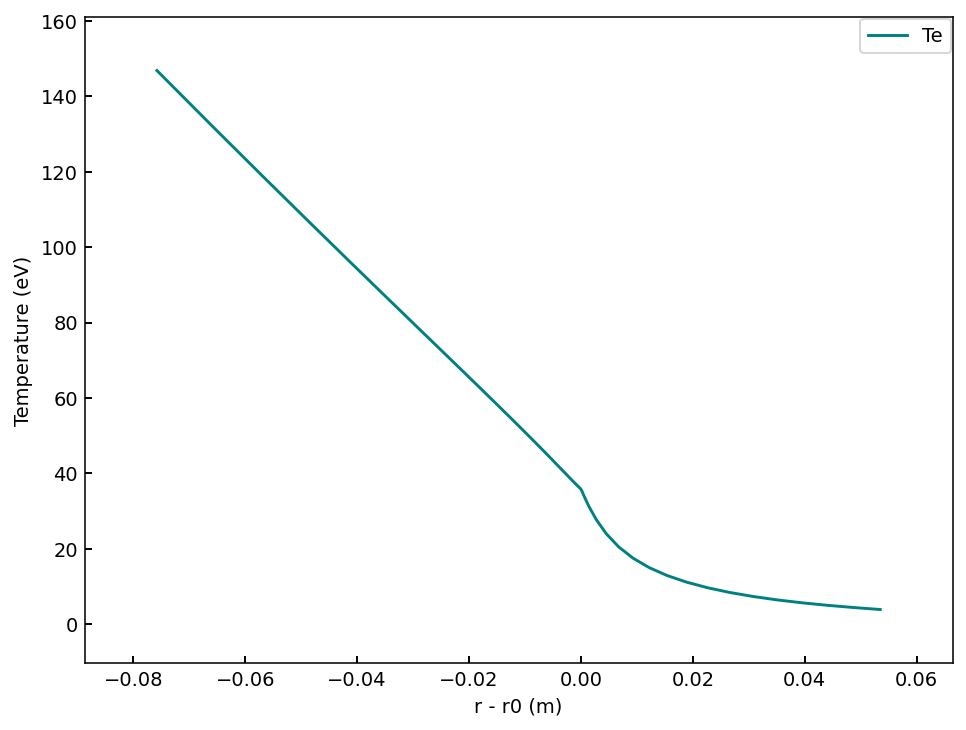

In [9]:
# Now we will plot some radial data at the OMP
params = ['Te']

rline = case.get_1d_radial_data(params, region='omp')

fig, ax = plt.subplots(figsize=(8,6))

ax.plot(rline['dist'], rline['Te'], label='Te')
ax.set_xlabel('r - r0 (m)')
ax.set_ylabel('Temperature (eV)')
ax.legend()


# Conclusion

Hope this has been a simple overview. There's a ton more in solps_pp.py, and contains some really useful blueprints  that we can incoporate into more complex analysis, such as how to select specific regions of the plasma. Hopefully we can get David's time dependant simulations soon. I think the most important next steps with this analysis is to:

- Plot the radial neutral density and pressure on the outer lower leg(and prepare to do this during the transient)
    - Is there a localised neutral pressure increase during a transient?
        - Does it drive neutral cross field transport?

- Determine the dominant mechanism of ion-neutral momentum transfer, specifically how important is charge exchange

- Fix get_1d_radial_data() at the target and determine neutral behaviour at the wall (speficially the impact of SOLPS more realistic neutral boundary conditions compared to Hermes-3 purely reflective target)

# Neutral vectors

In [10]:
import pickle
p = "/Users/lloyd/Documents/solps/puff=13.0e21_pump=0.001_divchiconstfix_bcmom2_visper1_rxf0p1_parmvsa2_redoutpfrtrans_pufflfs_pin1.0/fort.46"
try:
    with open(p, "rb") as f:
        d = pickle.load(f)
    print("Loaded pickle, keys:", getattr(d, "keys", lambda: None)())
except Exception as e:
    print("Not a pickle:", e)

Not a pickle: invalid load key, ' '.


FileNotFoundError: [Errno 2] No such file or directory: '/Users/lloyd/Documents/solps/puff=13.0e21_pump=0.001_divchiconstfix_bcmom2_visper1_rxf0p1_parmvsa2_redoutpfrtrans_pufflfs_pin1.0/triangle_mesh.pkl'

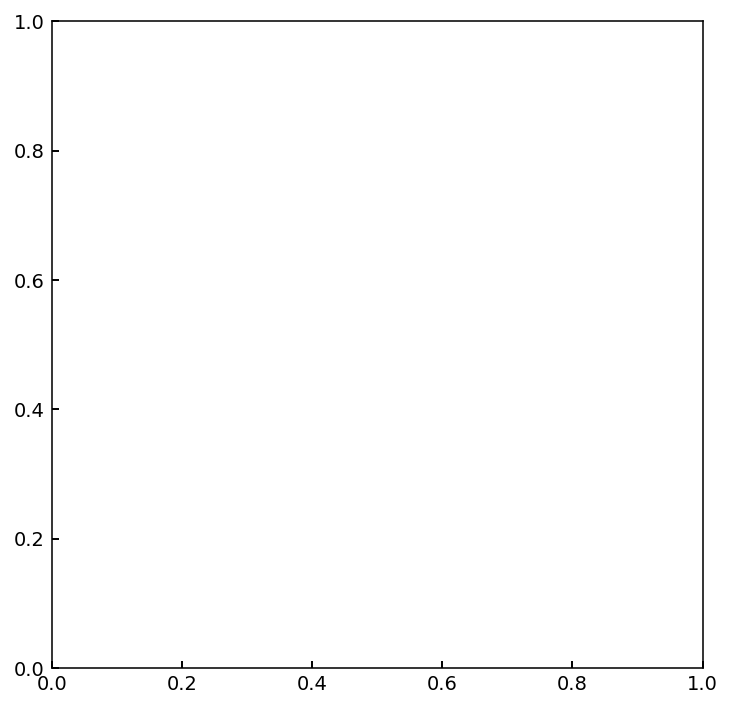

In [11]:
fig,ax = plt.subplots(figsize=(6,6))
case.plot_neutral_vectors(ax, flux=True, normalise_arrows=False, scale_mult=2, cmap="viridis")